# 🌱 Synthetic Dataset Generator — Paprika Hidroponik Adaptif
**Kolom:** `n, p, k, ec_aktual, kelembapan_udara, kelembapan_tanah, suhu, ph_tanah, fase, target_ec`

- Fase **Vegetatif** → base EC = **1.6 mS/cm**
- Fase **Generatif** → base EC = **2.0 mS/cm**
- Penyesuaian dinamis via **VPD**, kondisi media, & kelembapan tanah

## Cell 1 — Import Library
Pastikan sudah `pip install pandas numpy matplotlib seaborn`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
print('✅ Library siap')

✅ Library siap


## Cell 2 — Generate Fitur Input (X)
Nilai N, P, K dipisah dan disesuaikan dengan fase tanaman.
- **Vegetatif** → N tinggi, K sedang
- **Generatif** → K tinggi, N lebih rendah

In [3]:
np.random.seed(42)
n_samples = 5000

# Fase: 0 = Vegetatif, 1 = Generatif
fase = np.random.choice([0, 1], n_samples, p=[0.55, 0.45])
is_veg = (fase == 0)
is_gen = ~is_veg

# ── Suhu & Kelembapan Udara (berkorelasi negatif) ──
suhu = np.where(
    is_veg,
    np.random.normal(26.5, 2.0, n_samples),
    np.random.normal(28.5, 2.2, n_samples)
).clip(20, 35) # batas suhu realistis

# Kelembapan udara berkorelasi negatif dengan suhu + noise
kelembapan_udara = np.clip(
    85 - 0.9 * (suhu - 25) + np.random.normal(0, 5, n_samples),
    40, 95
)

# ── N, P, K (ppm) — tiap nutrisi punya range sendiri ──
# Vegetatif: N dominan; Generatif: K dominan
n_ppm = np.where(
    is_veg,
    np.random.uniform(180, 250, n_samples),   # N tinggi
    np.random.uniform(120, 180, n_samples)    # N lebih rendah
).round(2)

p_ppm = np.where(
    is_veg,
    np.random.uniform(40,  65, n_samples),    # P sedang
    np.random.uniform(50,  80, n_samples)     # P sedikit naik
).round(2)

k_ppm = np.where(
    is_veg,
    np.random.uniform(150, 210, n_samples),   # K sedang
    np.random.uniform(220, 300, n_samples)    # K tinggi
).round(2)

# ── EC Aktual: mendekati target + noise sensor ──
base_ec     = np.where(is_veg, 1.6, 2.0) # EC target: 1.6 untuk vegetatif, 2.0 untuk generatif
ec_aktual   = np.clip(
    base_ec + np.random.normal(0, 0.12, n_samples),
    0.8, 3.5
).round(3)

# kelembapakan tanah: 30–85% (ideal 40–70%) - dipilih biar mencangku kondisi kering dan ideal
kelembapan_tanah = np.random.uniform(30, 85, n_samples).round(2) 

usia_hst = np.where(
    is_veg,
    np.random.randint(7, 45, n_samples),   # Vegetatif: 7–45 HST
    np.random.randint(46, 150, n_samples)  # Generatif: 46–150 HST
)

# perakitan bro
df = pd.DataFrame({
    'n'                : n_ppm,
    'p'                : p_ppm,
    'k'                : k_ppm,
    'ec_aktual'        : ec_aktual,
    'kelembapan_udara' : kelembapan_udara.round(2),
    'kelembapan_tanah' : kelembapan_tanah,
    'suhu'             : suhu.round(2),
    'fase'             : fase,   # 0 = Vegetatif, 1 = Generatif
    'usia_hst'         : usia_hst
})

print(f'Shape  : {df.shape}')
print(f'Vegetatif : {is_veg.sum()} | Generatif : {is_gen.sum()}')
display(df.head(10))

Shape  : (5000, 9)
Vegetatif : 2748 | Generatif : 2252


,n,p,k,ec_aktual,kelembapan_udara,kelembapan_tanah,suhu,fase,usia_hst
0,189.57,52.66,150.01,1.627,69.96,35.96,25.31,0,38
1,176.22,79.95,253.78,2.088,78.55,77.89,29.26,1,130
2,153.75,57.73,277.53,2.108,79.47,65.23,26.33,1,120
3,170.57,51.85,254.36,2.052,83.89,65.49,28.18,1,48
4,247.72,63.67,200.13,1.529,95.00,52.25,27.58,0,22
5,186.22,52.49,181.02,1.644,86.36,52.73,27.36,0,30
6,213.43,48.44,181.60,1.629,95.00,46.67,25.94,0,20
7,120.13,67.92,251.89,2.007,83.59,53.89,29.73,1,87
8,156.81,67.76,245.71,2.064,78.23,62.29,29.02,1,106
9,141.36,51.30,236.20,1.847,85.99,40.26,25.84,1,68


## Cell 3 — Hitung VPD & Labeling Target EC

**VPD (Vapour Pressure Deficit)** = selisih tekanan uap jenuh vs aktual.

$$e_s = 0.6108 \times e^{\frac{17.27 \times T}{T + 237.3}} \quad (\text{kPa})$$
$$VPD = e_s - e_a = e_s \times \left(1 - \frac{RH}{100}\right)$$

**Aturan adaptasi EC:**
| Kondisi | Efek pada Target EC |
|---|---|
| VPD > 1.2 kPa (transpirasi tinggi) | −0.2 (larutan lebih encer) |
| VPD < 0.5 kPa (transpirasi rendah) | +0.2 (larutan lebih pekat) |
| EC aktual > 2.5 **atau** K > 260 ppm | −0.3 (cegah over-nutrisi) |
| Kelembapan tanah < 40% | −0.1 (media terlalu kering) |
| pH di luar range optimal (6.0–6.8) | ±0.15 |
| Noise realistis sensor | ±0.05 stdev |

In [4]:
def hitung_vpd(suhu, rh):
    """Hitung Vapour Pressure Deficit (kPa) — persamaan Magnus."""
    es = 0.6108 * np.exp((17.27 * suhu) / (suhu + 237.3))
    ea = es * (rh / 100)
    return es - ea


def hitung_target_ec(row):
    # ── Base EC sesuai fase ──
    target = 1.6 if row['fase'] == 0 else 2.0

    # ── Hitung VPD ──
    vpd = hitung_vpd(row['suhu'], row['kelembapan_udara'])

    # Rule 1 — VPD / Transpirasi
    if vpd > 1.2:
        target -= 0.2   # transpirasi tinggi → encerkan larutan
    elif vpd < 0.5:
        target += 0.2   # transpirasi rendah → padatkan larutan

    # Rule 2 — Over-nutrisi (EC aktual atau K terlalu tinggi)
    if row['ec_aktual'] > 2.5 or row['k'] > 260:
        target -= 0.3

    # Rule 3 — Media terlalu kering
    if row['kelembapan_tanah'] < 40:
        target -= 0.1

    target = max(0.8, min(target, 3.0))

    # Tambah noise sensor kecil
    target += np.random.normal(0, 0.05)

    return round(target, 2)


# Terapkan ke seluruh DataFrame
df['target_ec'] = df.apply(hitung_target_ec, axis=1)

# Simpan VPD sebagai kolom eksplisit (berguna untuk analisis)
df['vpd'] = hitung_vpd(df['suhu'], df['kelembapan_udara']).round(4)

# Simpan ke CSV
df.to_csv('dataset/dataset_paprika_adaptif.csv', index=False)
print('✅ Dataset disimpan → dataset_paprika_adaptif.csv')
print(f'Kolom : {list(df.columns)}')
display(df.describe().round(3))

✅ Dataset disimpan → dataset_paprika_adaptif.csv
Kolom : ['n', 'p', 'k', 'ec_aktual', 'kelembapan_udara', 'kelembapan_tanah', 'suhu', 'fase', 'usia_hst', 'target_ec', 'vpd']


,n,p,k,ec_aktual,kelembapan_udara,kelembapan_tanah,suhu,fase,usia_hst,target_ec,vpd
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,185.113,58.121,216.084,1.779,82.931,57.533,27.372,0.450,58.132,1.751,0.637
std,37.569,10.020,44.611,0.231,5.399,15.911,2.308,0.498,42.005,0.185,0.248
min,120.000,40.000,150.010,1.205,63.110,30.010,20.000,0.000,7.000,1.220,0.118
25%,152.468,50.860,177.088,1.589,79.278,43.752,25.780,0.000,24.000,1.610,0.465
50%,186.510,57.650,204.675,1.745,82.885,57.475,27.315,0.000,41.000,1.720,0.616
75%,217.510,64.262,256.122,1.984,86.610,71.382,28.900,1.000,92.000,1.870,0.791
max,249.970,79.970,299.990,2.406,95.000,84.980,35.000,1.000,149.000,2.330,1.767


## Cell 4 — EDA: Distribusi Target EC per Fase

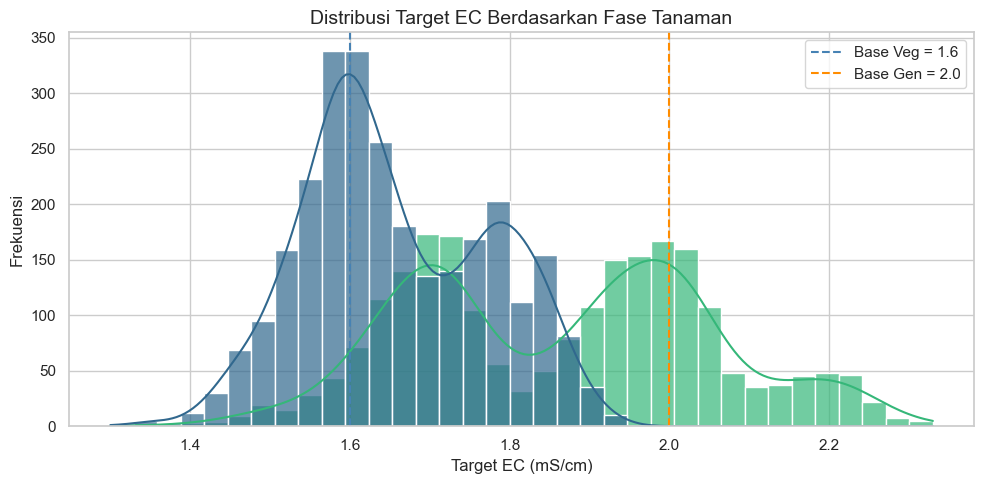

📊 Grafik disimpan → dist_target_ec.png


In [9]:
fase_label = df['fase'].map({0: 'Vegetatif', 1: 'Generatif'})

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df.assign(Fase=fase_label),
    x='target_ec', hue='Fase',
    kde=True, palette='viridis', bins=35, alpha=0.7
)
plt.axvline(1.6, color='steelblue',  linestyle='--', linewidth=1.5, label='Base Veg = 1.6')
plt.axvline(2.0, color='darkorange', linestyle='--', linewidth=1.5, label='Base Gen = 2.0')
plt.title('Distribusi Target EC Berdasarkan Fase Tanaman', fontsize=14)
plt.xlabel('Target EC (mS/cm)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('data/dist_target_ec.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → dist_target_ec.png')

## Cell 5 — EDA: VPD vs Target EC (Scatter)

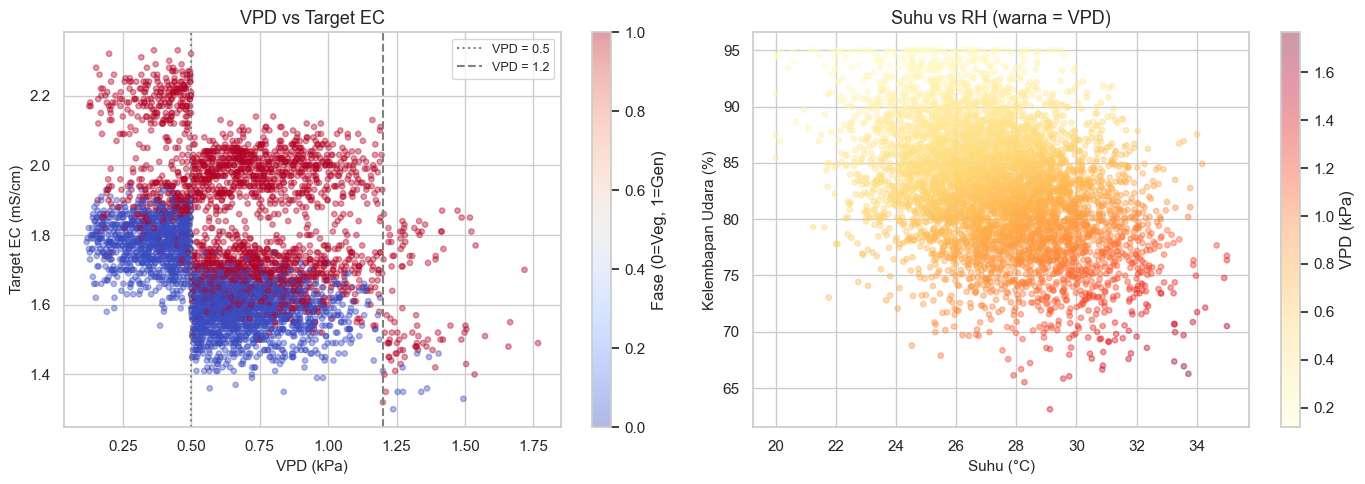

📊 Grafik disimpan → scatter_vpd_ec.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter VPD vs Target EC
sc = axes[0].scatter(
    df['vpd'], df['target_ec'],
    c=df['fase'], cmap='coolwarm', alpha=0.4, s=15
)
axes[0].axvline(0.5, color='gray', linestyle=':', label='VPD = 0.5')
axes[0].axvline(1.2, color='gray', linestyle='--', label='VPD = 1.2')
axes[0].set_xlabel('VPD (kPa)', fontsize=11)
axes[0].set_ylabel('Target EC (mS/cm)', fontsize=11)
axes[0].set_title('VPD vs Target EC', fontsize=13)
axes[0].legend(fontsize=9)
plt.colorbar(sc, ax=axes[0], label='Fase (0=Veg, 1=Gen)')

# Scatter Suhu vs Kelembapan Udara (warna = VPD)
sc2 = axes[1].scatter(
    df['suhu'], df['kelembapan_udara'],
    c=df['vpd'], cmap='YlOrRd', alpha=0.4, s=15
)
axes[1].set_xlabel('Suhu (°C)', fontsize=11)
axes[1].set_ylabel('Kelembapan Udara (%)', fontsize=11)
axes[1].set_title('Suhu vs RH (warna = VPD)', fontsize=13)
plt.colorbar(sc2, ax=axes[1], label='VPD (kPa)')

plt.tight_layout()
plt.savefig('data/scatter_vpd_ec.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → scatter_vpd_ec.png')

## Cell 6 — EDA: Heatmap Korelasi

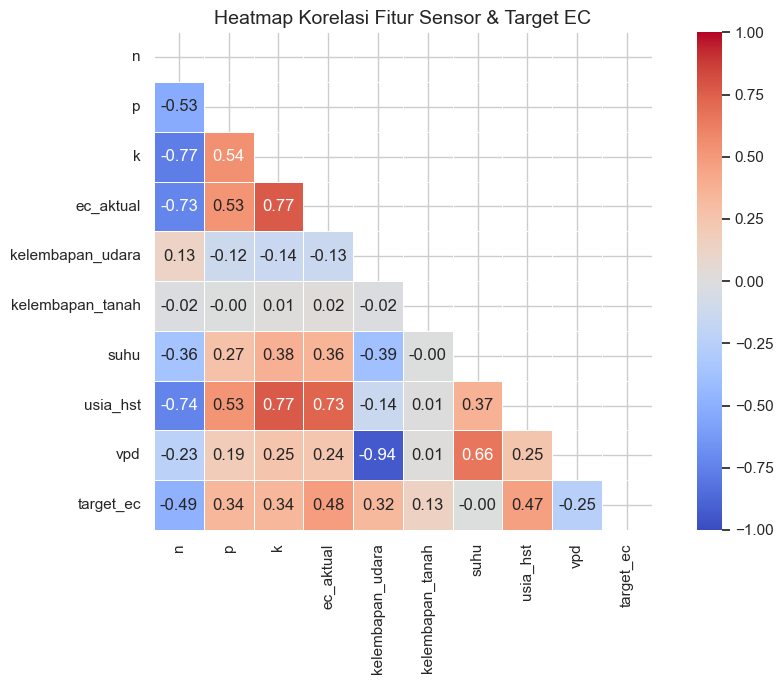

📊 Grafik disimpan → heatmap_korelasi.png


In [ ]:
plt.figure(figsize=(10, 7))
corr = df[['n','p','k','ec_aktual','kelembapan_udara',
            'kelembapan_tanah','suhu','usia_hst','vpd','target_ec']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title('Heatmap Korelasi Fitur Sensor & Target EC', fontsize=14)
plt.tight_layout()
plt.savefig('data/heatmap_korelasi.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → heatmap_korelasi.png')

## Cell 7 — EDA: Boxplot N, P, K per Fase

/var/folders/yx/nxpxg23556v18ggjdd6phyq40000gn/T/ipykernel_74061/674614518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yx/nxpxg23556v18ggjdd6phyq40000gn/T/ipykernel_74061/674614518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yx/nxpxg23556v18ggjdd6phyq40000gn/T/ipykernel_74061/674614518.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


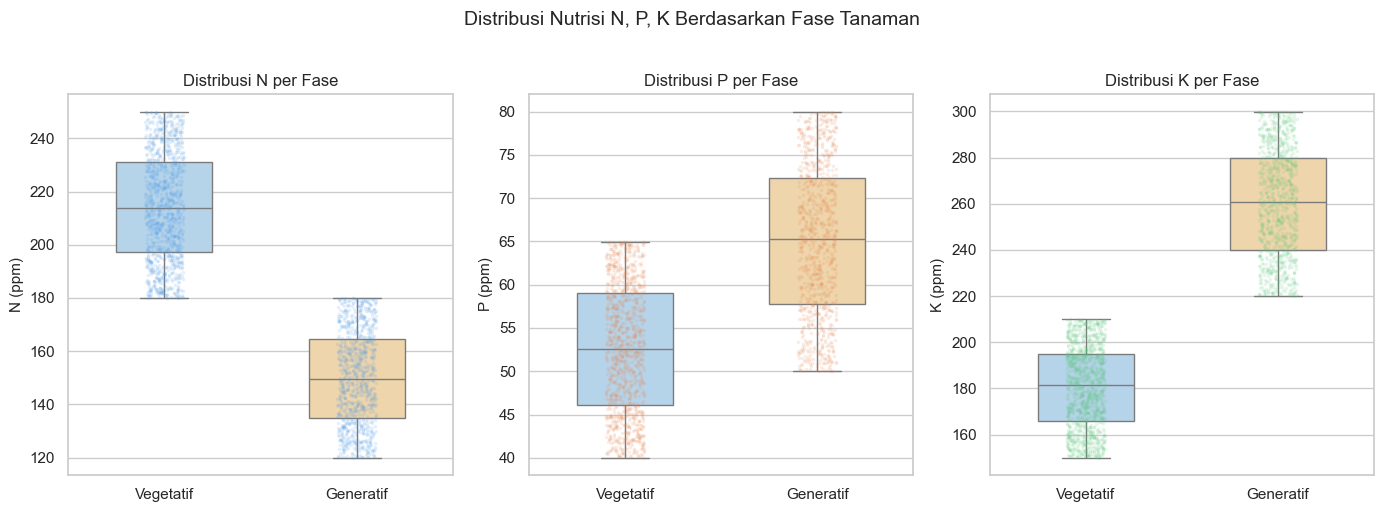

📊 Grafik disimpan → boxplot_npk.png


In [7]:
df_plot = df.assign(Fase=df['fase'].map({0: 'Vegetatif', 1: 'Generatif'}))

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, nutrisi, color in zip(axes, ['n', 'p', 'k'],
                               ['#4C9BE8', '#E8834C', '#58C97A']):
    sns.boxplot(
        data=df_plot, x='Fase', y=nutrisi,
        palette=['#AED6F1', '#FAD7A0'], ax=ax,
        width=0.5, fliersize=3
    )
    sns.stripplot(
        data=df_plot, x='Fase', y=nutrisi,
        color=color, alpha=0.15, size=2.5, ax=ax, jitter=True
    )
    ax.set_title(f'Distribusi {nutrisi.upper()} per Fase', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(f'{nutrisi.upper()} (ppm)', fontsize=11)

plt.suptitle('Distribusi Nutrisi N, P, K Berdasarkan Fase Tanaman', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('boxplot_npk.png', dpi=150)
plt.show()
print('📊 Grafik disimpan → boxplot_npk.png')

## Cell 8 — Statistik Ringkas per Fase

In [8]:
summary = (
    df_plot
    .groupby('Fase')[['n','p','k','ec_aktual','suhu',
                       'kelembapan_udara','vpd','target_ec']]
    .agg(['mean','std','min','max'])
    .round(3)
)

print('=== Statistik Deskriptif per Fase ===')
display(summary)

=== Statistik Deskriptif per Fase ===


n                               p                       \
              mean     std     min     max    mean    std    min    max   
Fase                                                                      
Generatif  150.040  17.373  120.08  179.93  65.103  8.553  50.01  80.00   
Vegetatif  214.226  19.904  180.02  249.98  52.599  7.233  40.03  64.99   

                 k          ... kelembapan_udara          vpd                \
              mean     std  ...              min   max   mean    std    min   
Fase                        ...                                               
Generatif  260.191  22.941  ...            64.63  95.0  0.715  0.252  0.134   
Vegetatif  180.431  17.399  ...            65.13  95.0  0.583  0.226  0.134   

                 target_ec                     
             max      mean    std   min   max  
Fase                                           
Generatif  1.757     1.846  0.200  1.31  2.39  
Vegetatif  1.743     1.580  0.141  1.02  1.96  

[2 rows x 32 columns]